In [18]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 51.406696,
	"longitude": -0.288789,
	"start_date": "2025-04-21",
	"end_date": "2025-04-21",
	"hourly": "temperature_2m",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	)
}

hourly_data["temperature_2m"] = hourly_temperature_2m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)


Coordinates: 51.42354965209961°N -0.325469970703125°E
Elevation: 13.0 m asl
Timezone difference to GMT+0: 0s

Hourly data
                         date  temperature_2m
0  2025-04-21 00:00:00+00:00        9.750000
1  2025-04-21 01:00:00+00:00        9.950000
2  2025-04-21 02:00:00+00:00        9.850000
3  2025-04-21 03:00:00+00:00        9.900000
4  2025-04-21 04:00:00+00:00       10.000000
5  2025-04-21 05:00:00+00:00       10.000000
6  2025-04-21 06:00:00+00:00       10.050000
7  2025-04-21 07:00:00+00:00       10.300000
8  2025-04-21 08:00:00+00:00       11.050000
9  2025-04-21 09:00:00+00:00       12.350000
10 2025-04-21 10:00:00+00:00       13.850000
11 2025-04-21 11:00:00+00:00       15.100000
12 2025-04-21 12:00:00+00:00       15.950000
13 2025-04-21 13:00:00+00:00       16.100000
14 2025-04-21 14:00:00+00:00       16.950001
15 2025-04-21 15:00:00+00:00       12.800000
16 2025-04-21 16:00:00+00:00       12.650000
17 2025-04-21 17:00:00+00:00       13.400000
18 2025-04-21 18:00:00

In [8]:
print(hourly_temperature_2m)

[ 5.65  5.6   4.95  4.45  3.85  3.45  3.85  5.45  7.35  9.05 10.2  11.05
 11.8  11.6  12.25 12.3  12.85 12.45 12.5  11.35 10.3   9.75  8.9   8.15]


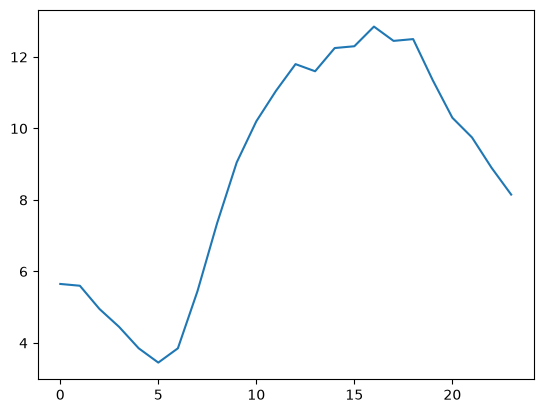

In [10]:
import matplotlib.pyplot as plt
hours = list(range(0,24))
temps = hourly_temperature_2m
plt.plot(hours,temps)
plt.show()

In [7]:
print(hours)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


dT/dt = -k(T - Ta)

In [19]:
import pandas as pd 
df = pd.read_csv(
    "1644725-temp.csv",
    header=None,
    names=["timestamp", "indoor_temp"])

df["time"] = pd.to_datetime(df["timestamp"], unit="s", utc=True).dt.tz_convert("Europe/London")
hourly_indoor = (
    df.set_index("time")["indoor_temp"]
      .resample("1h")
      .mean())
print(hourly_indoor)


time
2024-12-10 12:00:00+00:00    17.523333
2024-12-10 13:00:00+00:00    17.602605
2024-12-10 14:00:00+00:00    17.622437
2024-12-10 15:00:00+00:00    17.702250
2024-12-10 16:00:00+00:00    17.844118
                               ...    
2025-12-05 19:00:00+00:00    17.157563
2025-12-05 20:00:00+00:00    17.260840
2025-12-05 21:00:00+00:00    17.318750
2025-12-05 22:00:00+00:00    17.313583
2025-12-05 23:00:00+00:00    17.256639
Freq: h, Name: indoor_temp, Length: 8652, dtype: float64


In [16]:
day = "2025-04-21"

indoor_day = hourly_indoor.loc[day]

print(indoor_day)
print(len(indoor_day))

time
2025-04-21 00:00:00+01:00    17.378276
2025-04-21 01:00:00+01:00    17.240667
2025-04-21 02:00:00+01:00    17.127143
2025-04-21 03:00:00+01:00    17.023417
2025-04-21 04:00:00+01:00    16.937069
2025-04-21 05:00:00+01:00    16.871092
2025-04-21 06:00:00+01:00    16.821271
2025-04-21 07:00:00+01:00    16.837479
2025-04-21 08:00:00+01:00    16.976975
2025-04-21 09:00:00+01:00    16.883898
2025-04-21 10:00:00+01:00    16.850084
2025-04-21 11:00:00+01:00    16.952689
2025-04-21 12:00:00+01:00    17.230588
2025-04-21 13:00:00+01:00    17.506417
2025-04-21 14:00:00+01:00    17.649492
2025-04-21 15:00:00+01:00    17.614874
2025-04-21 16:00:00+01:00    17.301176
2025-04-21 17:00:00+01:00    17.351849
2025-04-21 18:00:00+01:00    17.462250
2025-04-21 19:00:00+01:00    17.534492
2025-04-21 20:00:00+01:00    17.855339
2025-04-21 21:00:00+01:00    18.198250
2025-04-21 22:00:00+01:00    18.352735
2025-04-21 23:00:00+01:00    18.240083
Freq: h, Name: indoor_temp, dtype: float64
24


In [24]:
import numpy as np

in_vs_out = pd.DataFrame({
    "indoor": indoor_day.to_numpy(),
    "outdoor": hourly_data["temperature_2m"]
}, index=indoor_day.index)

in_vs_out["indoor"] = pd.to_numeric(in_vs_out["indoor"])
in_vs_out["outdoor"] = pd.to_numeric(in_vs_out["outdoor"])

in_vs_out["indoor_next"] = in_vs_out["indoor"].shift(-1)

in_vs_out["k"] = -np.log((in_vs_out["indoor_next"] - in_vs_out["outdoor"]) / (in_vs_out["indoor"] - in_vs_out["outdoor"]))  # finding k by rearranging formula to -1/deltat(next temp - out temp) / (indoor temp - outdoor temp)

print(in_vs_out)

                              indoor    outdoor  indoor_next         k
time                                                                  
2025-04-21 00:00:00+01:00  17.378276   9.750000    17.240667  0.018204
2025-04-21 01:00:00+01:00  17.240667   9.950000    17.127143  0.015694
2025-04-21 02:00:00+01:00  17.127143   9.850000    17.023417  0.014356
2025-04-21 03:00:00+01:00  17.023417   9.900000    16.937069  0.012196
2025-04-21 04:00:00+01:00  16.937069  10.000000    16.871092  0.009556
2025-04-21 05:00:00+01:00  16.871092  10.000000    16.821271  0.007277
2025-04-21 06:00:00+01:00  16.821271  10.050000    16.837479 -0.002391
2025-04-21 07:00:00+01:00  16.837479  10.300000    16.976975 -0.021113
2025-04-21 08:00:00+01:00  16.976975  11.050000    16.883898  0.015828
2025-04-21 09:00:00+01:00  16.883898  12.350000    16.850084  0.007486
2025-04-21 10:00:00+01:00  16.850084  13.850000    16.952689 -0.033629
2025-04-21 11:00:00+01:00  16.952689  15.100000    17.230588 -0.139760
2025-0

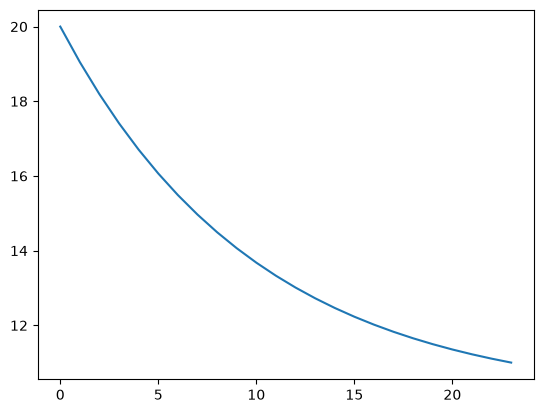

[20.0, 19.048374180359595, 18.18730753077982, 17.40818220681718, 16.703200460356392, 16.065306597126334, 15.488116360940264, 14.965853037914094, 14.493289641172215, 14.065696597405992, 13.678794411714424, 13.328710836980795, 13.011942119122022, 12.725317930340125, 12.465969639416064, 12.231301601484299, 12.018965179946555, 11.826835240527346, 11.652988882215865, 11.495686192226351, 11.353352832366127, 11.224564282529819, 11.108031583623339, 11.002588437228038]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

T0 = 20
Tout = 10
k = 0.1
dt = 1
hours = 24
# T(t) = Tout + (T0 - Tout)*e^(-kt)

#Tout + (T0 - Tout)*math.e**(-k*t)
times = []
temps = []

for t in range(0,hours):
    temp = Tout + (T0 - Tout)*math.e**(-k*t)
    times.append(t)
    temps.append(temp)

plt.plot(times,temps)
plt.show()

print(temps)

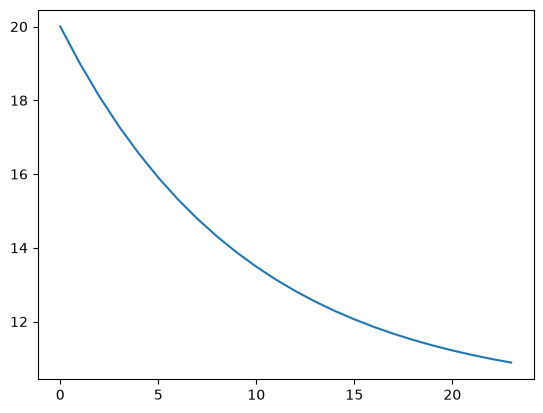

In [32]:
T0 = 20
Tout = 10
k = 0.1
dt = 1
hours = 24
times = []
temps = [T0]
for t in range(0,hours):
    times.append(t)
    T = temps[t]
    newtemp = T + (dt*(-1*k*((T - Tout))))
    temps.append(newtemp)

temps.pop()
plt.plot(times,temps)
plt.show()